# Факторный анализ

## Дескриптивный анализ. Согласованность выборок с нормальным распределением. Корреляционный анализ

Размер датасета: (1100, 21)

Первые строки:
   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_conditions  ...  basic_needs  academic_performance  study_load  \
0 

/var/folders/mh/7kxb_s251w94ps4mx9142hxc0000gn/T/ipykernel_22223/4257047684.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="stress_level", data=df, palette="viridis")


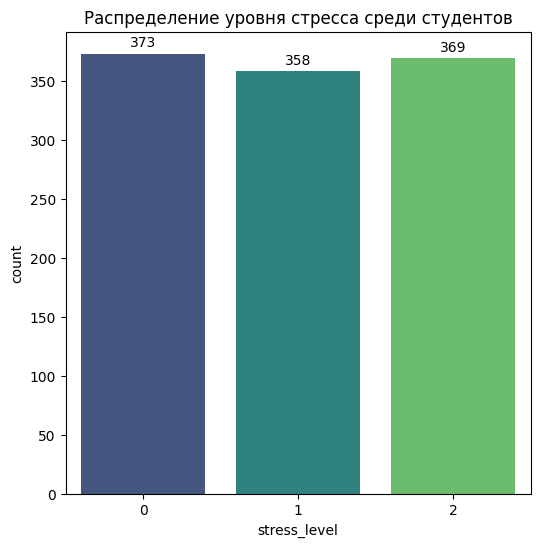

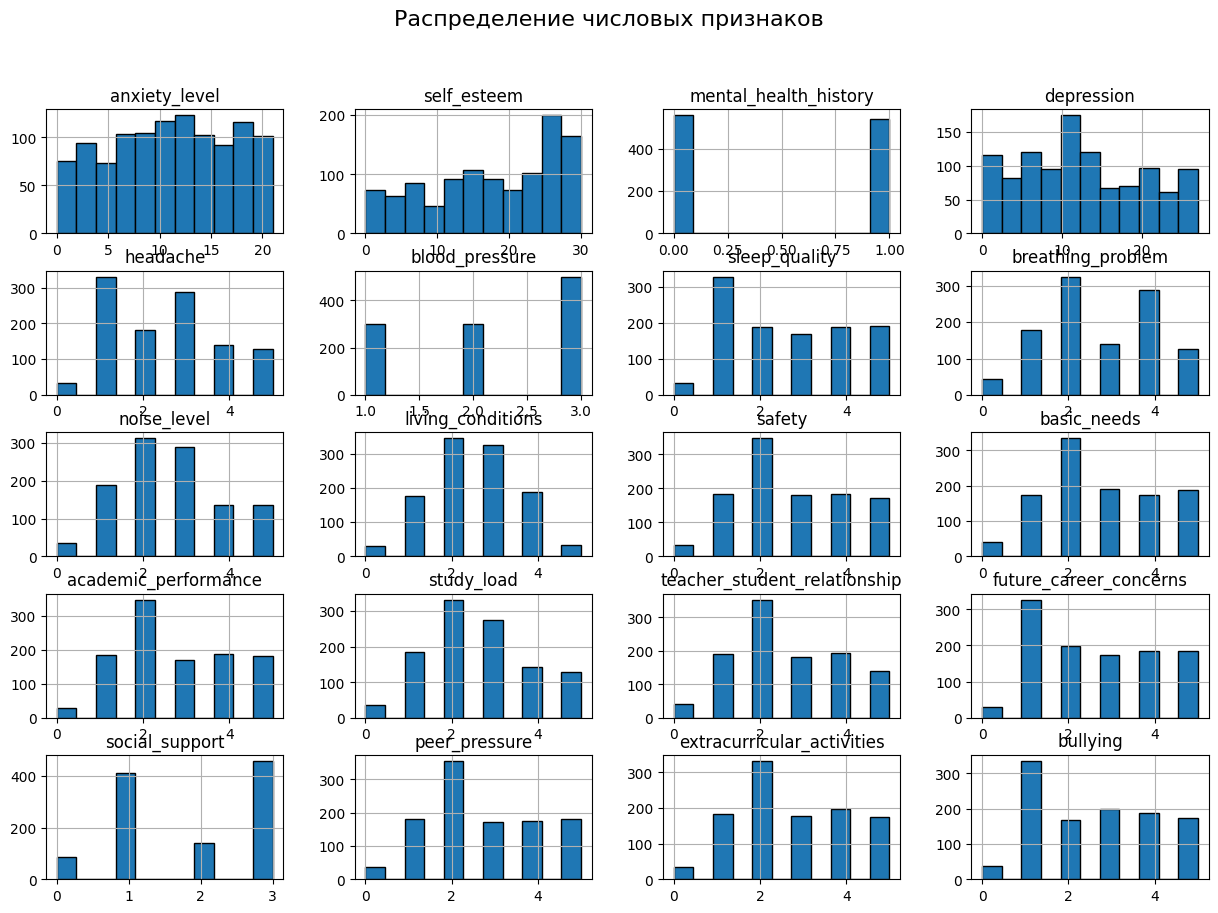

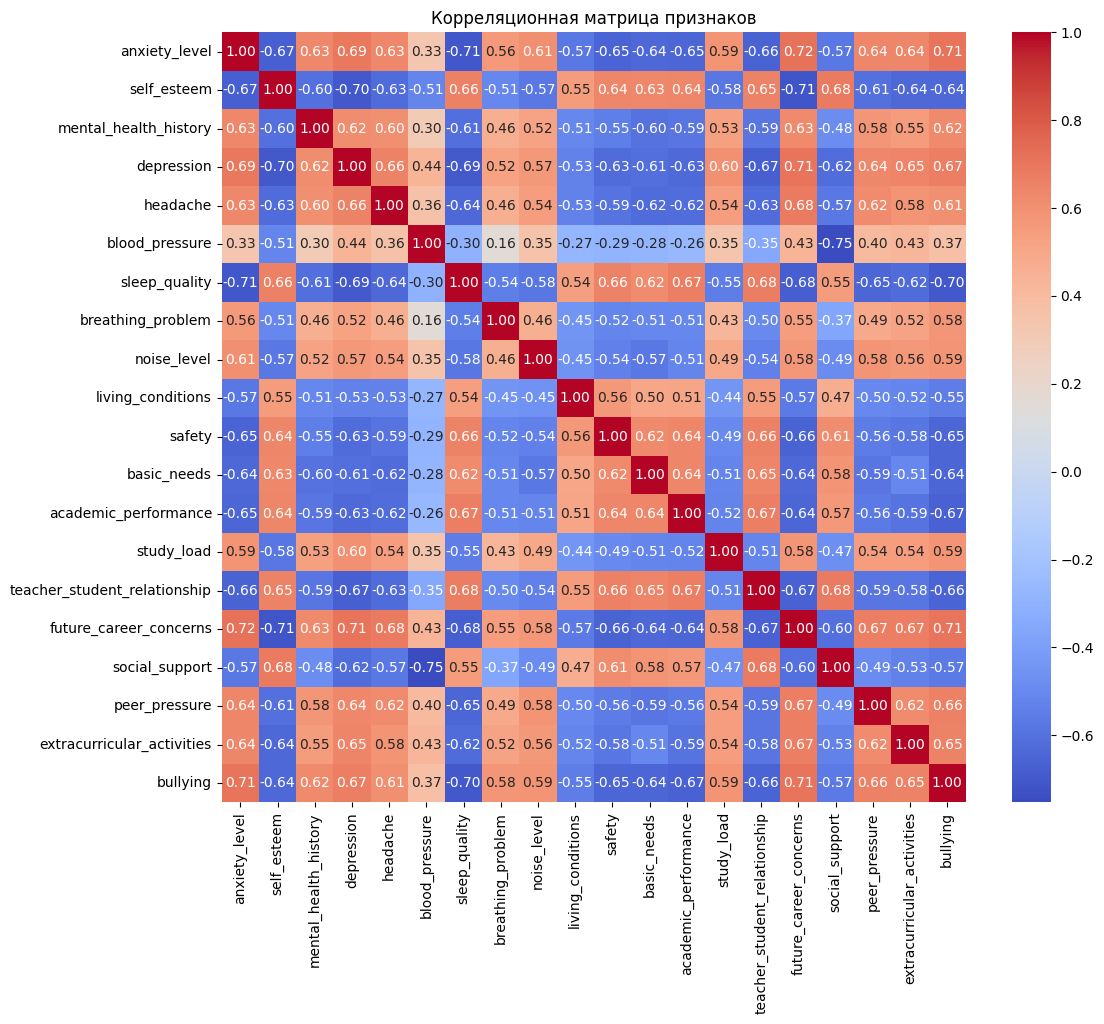

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, normaltest
import seaborn as sns

# Загрузка данных
df = pd.read_csv('StressLevelDataset.csv')
df = df.fillna(df.mean(numeric_only=True))

# Описание и базовый анализ
num_cols = df.columns.drop('stress_level')

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe())
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Асимметрия и эксцесс
param_data = {'Параметр': [], 'Асимметрия': [], 'Эксцесс': []}
for col in num_cols:
    param_data['Параметр'].append(col)
    param_data['Асимметрия'].append(skew(df[col].dropna()))
    param_data['Эксцесс'].append(kurtosis(df[col].dropna()))
summary_df = pd.DataFrame(param_data)
print(summary_df)

# Нормальность распределения (тест Д’Агостино-Пирсона)
print("\nПроверка нормальности распределения:")
for col in num_cols:
    stat, p = normaltest(df[col].dropna())
    print(f"{col}: статистика={stat:.4f}, p-значение={p:.4f}")
    if p > 0.05:
        print(" → распределение близко к нормальному\n")
    else:
        print(" → распределение отличается от нормального\n")

# График распределения значений stress_level
plt.figure(figsize=(6, 6))
ax = sns.countplot(x="stress_level", data=df, palette="viridis")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title("Распределение уровня стресса среди студентов")
plt.show()

# Гистограммы для числовых признаков
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))
df[num_cols].hist(bins=count_of_bins, figsize=(15, 10), edgecolor="black")
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

# Корреляционный анализ
plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

## Предположения о наличии скрытых факторов

1. Психологический фактор
- Признаки anxiety_level, depression, mental_health_history, headache и bullying обладают высокими положительными корреляциями между собой (0.63–0.71). Это может свидетельствовать о существовании мощного общего психологического фактора, объединяющего тревожность, депрессию, психосоматические жалобы и влияние травмирующих социальных событий.​

- Самооценка (self_esteem) демонстрирует сильные отрицательные связи с anxiety_level и depression (около -0.67 и -0.70), что может быть проявлением отдельного антистрессового или адаптационного фактора.​

2. Социальный фактор
- Признаки bullying, social_support, peer_pressure и teacher_student_relationship частично коррелируют друг с другом (от -0.64 до 0.66). Это может отражать скрытое влияние социальных условий, поддержки и взаимоотношений в коллективе на уровень стресса.​

- Noise_level, living_conditions, safety и basic_needs также имеют умеренные положительные корреляции между собой и с психологическими признаками (до 0.62). Это указывает на возможный фактор внешней среды или быта.​

3. Фактор академических успехов
- academic_performance и study_load отрицательно коррелируют с признаками тревожности и депрессии (от -0.58 до -0.65), и положительно с самооценкой и социальной поддержкой (до 0.64). Можно предположить наличие академического мотивационного фактора.​

4. Гипотезы о скрытых факторах
- Возможно, 3-4 латентных компонента: психологический дистресс, неблагоприятная среда/социальная поддержка, академическая нагрузка/успех и фактор адаптации (самооценка, поддержка).

Эти факторы определяются не только исходными признаками, но и их групповыми влияниями, отраженными в структуре корреляций.

## Стандартизация признаков и проверка критерия КМО и Бартлетта

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Проверим первые строки стандартизированного датасета и описательные статистики
scaled_head = df_scaled.head()
scaled_stats = df_scaled[num_cols].describe()
scaled_head, scaled_stats

(   anxiety_level  self_esteem  mental_health_history  depression  headache  \
 0       0.480208     0.248612              -0.985559   -0.201393 -0.360741   
 1       0.643746    -1.093590               1.014653    0.316508  1.768859   
 2       0.153131     0.024912               1.014653    0.187033 -0.360741   
 3       0.807284    -0.646189               1.014653    0.316508  1.058992   
 4       0.807284     1.143414              -0.985559   -0.719293 -0.360741   
 
    blood_pressure  sleep_quality  breathing_problem  noise_level  \
 0       -1.418416      -0.426445           0.890211    -0.488949   
 1        0.981981      -1.072574           0.890211     0.264334   
 2       -1.418416      -0.426445          -0.538282    -0.488949   
 3        0.981981      -1.072574           0.175964     1.017616   
 4        0.981981       1.511942          -1.252529     0.264334   
 
    living_conditions  ...  basic_needs  academic_performance  study_load  \
 0           0.430695  ...    -

In [38]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Критерий Кайзера-Мейера-Олкина (KMO)
kmo_all, kmo_model = calculate_kmo(df_scaled)

# Критерий сферичности Бартлетта
bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(df_scaled)

print(f"Значение КМО: {kmo_model}")
print(f"Значение статистики хи-квадрат (Бартлетт): {bartlett_chi2}")
print(f"Значение вероятности p (Бартлетт): {bartlett_p}")

Значение КМО: 0.9712055827228684
Значение статистики хи-квадрат (Бартлетт): 19237.225176575783
Значение вероятности p (Бартлетт): 0.0


/Users/ilavoronin/Учеба/СИИиМО/myenv/lib/python3.13/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


### Анализ полученных результатов

Полученные значения критериев КМО и Бартлетта однозначно свидетельствуют о том, что данные подходят для факторного анализа:

- Значение КМО = 0.97 — очень высокий показатель (выше 0.9 считается превосходным). Это говорит о том, что переменные достаточно хорошо коррелируют между собой и все признаки пригодны для выделения латентных факторов.​

- Статистика Бартлетта: хи-квадрат = 19237.23 при p-значении = 0.0 (меньше 0.05) означает, что корреляционная матрица значимо отличается от единичной, то есть признаки не являются независимыми и факторизация оправдана.​

## Определение скрытых факторов

### PCA

In [39]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X = scaler.fit_transform(df[num_cols])

# PCA (n_components по количеству признаков)
pca = PCA(n_components=len(num_cols))
pca.fit(X)

# Матрица компонентных нагрузок (компоненты x признаки)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(num_cols))], index=num_cols)

# Таблица собственных значений и объяснённой дисперсии
explained_var = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
eigen_table = pd.DataFrame({
    'Собственное значение': explained_var,
    'Доля объяснённой дисперсии': explained_ratio,
    'Накопленная дисперсия': explained_ratio.cumsum()
}, index=[f'PC{i+1}' for i in range(len(num_cols))])

loadings, eigen_table

(                                   PC1       PC2       PC3       PC4  \
 anxiety_level                 0.244210 -0.111202  0.058005  0.006182   
 self_esteem                  -0.242044 -0.150199  0.038901 -0.051040   
 mental_health_history         0.218941 -0.117788  0.072320 -0.328248   
 depression                    0.242709  0.043185  0.073336 -0.058009   
 headache                      0.229389 -0.013205 -0.027857 -0.267806   
 blood_pressure                0.145111  0.744363  0.130590  0.146565   
 sleep_quality                -0.240323  0.135088  0.026644  0.060489   
 breathing_problem             0.189994 -0.299804  0.114598  0.626761   
 noise_level                   0.208863 -0.015763  0.274080 -0.013605   
 living_conditions            -0.198625  0.095542  0.196512 -0.362485   
 safety                       -0.229310  0.084732  0.345697 -0.129479   
 basic_needs                  -0.226792  0.106257  0.246109  0.244954   
 academic_performance         -0.229500  0.135897  

### Анализ исполнения PCA

|                               | PC1       | PC2       | PC3       | PC4       | PC5       | PC6       | PC7       | PC8       | PC9       | PC10      | PC11      | PC12      | PC13      | PC14      | PC15      | PC16      | PC17      | PC18      | PC19      | PC20      |
|-------------------------------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
| anxiety_level                 | 0.244210  | -0.111202 | 0.058005  | 0.006182  | 0.003454  | 0.004318  | -0.016306 | -0.094467 | 0.140731  | -0.098298 | 0.276250  | -0.015880 | -0.193493 | 0.478546  | -0.124260 | 0.214166  | -0.235581 | 0.642864  | -0.088250 | 0.070877  |
| self_esteem                   | -0.242044 | -0.150199 | 0.038901  | -0.051040 | -0.004427 | 0.094123  | -0.052974 | -0.030701 | -0.122830 | -0.206056 | -0.094772 | 0.285748  | 0.532789  | 0.290037  | -0.061081 | -0.176777 | 0.194570  | 0.228786  | 0.509568  | 0.033211  |
| mental_health_history         | 0.218941  | -0.117788 | 0.072320  | -0.328248 | -0.209005 | 0.001616  | -0.058415 | 0.514959  | 0.635360  | 0.028800  | 0.037351  | -0.038671 | 0.261336  | -0.105060 | 0.137678  | 0.050775  | 0.023375  | 0.002652  | 0.059290  | -0.024385 |
| depression                    | 0.242709  | 0.043185  | 0.073336  | -0.058009 | -0.008586 | -0.182565 | -0.101952 | -0.037375 | -0.042794 | 0.193775  | 0.433867  | 0.119549  | -0.136949 | -0.125916 | -0.192660 | -0.335668 | 0.664422  | 0.129080  | -0.015624 | -0.024762 |
| headache                      | 0.229389  | -0.013205 | -0.027857 | -0.267806 | -0.157824 | 0.078316  | -0.160625 | 0.199475  | -0.514513 | 0.523406  | -0.075529 | 0.022589  | 0.231173  | 0.276834  | 0.162559  | -0.060951 | -0.124884 | -0.000974 | -0.235049 | 0.046068  |
| blood_pressure                | 0.145111  | 0.744363  | 0.130590  | 0.146565  | 0.014058  | 0.009050  | 0.000233  | 0.165256  | 0.022189  | -0.094267 | -0.064582 | 0.048606  | 0.004848  | 0.076259  | 0.144469  | -0.043508 | 0.021029  | 0.045330  | 0.119256  | 0.545443  |
| sleep_quality                 | -0.240323 | 0.135088  | 0.026644  | 0.060489  | -0.073122 | 0.043886  | 0.234271  | 0.182013  | -0.007513 | 0.129901  | -0.340277 | -0.178960 | 0.146518  | 0.017024  | -0.384047 | 0.400215  | 0.421862  | 0.250015  | -0.296689 | -0.040938 |
| breathing_problem             | 0.189994  | -0.299804 | 0.114598  | 0.626761  | 0.344634  | -0.211903 | 0.205398  | 0.426926  | -0.107412 | 0.131113  | 0.027907  | 0.123974  | 0.099174  | -0.044494 | 0.126025  | 0.051874  | -0.021307 | 0.030709  | 0.056393  | 0.009262  |
| noise_level                   | 0.208863  | -0.015763 | 0.274080  | -0.013605 | 0.269619  | 0.710258  | 0.274728  | -0.260309 | 0.165601  | 0.238087  | 0.030770  | 0.150546  | 0.027518  | 0.027134  | 0.084880  | 0.100273  | 0.124331  | -0.129834 | 0.027308  | -0.029860 |
| living_conditions             | -0.198625 | 0.095542  | 0.196512  | -0.362485 | 0.781777  | -0.223964 | -0.230121 | 0.016033  | 0.042803  | 0.067601  | 0.061265  | -0.168212 | 0.128414  | 0.027513  | -0.023079 | 0.064274  | -0.045005 | 0.008151  | -0.066150 | 0.005575  |
| safety                        | -0.229310 | 0.084732  | 0.345697  | -0.129479 | -0.052540 | -0.006597 | -0.053327 | 0.319550  | -0.011665 | 0.047486  | -0.094876 | 0.605673  | -0.420371 | 0.104894  | -0.248873 | 0.006078  | -0.148084 | -0.102555 | 0.017244  | -0.188522 |
| basic_needs                   | -0.226792 | 0.106257  | 0.246109  | 0.244954  | -0.218278 | -0.208411 | -0.295228 | -0.280079 | 0.135224  | 0.130823  | 0.233095  | 0.200635  | 0.216070  | 0.099018  | 0.383120  | 0.400150  | 0.118809  | -0.101372 | -0.153783 | -0.136375 |
| academic_performance          | -0.229500 | 0.135897  | 0.263309  | 0.149518  | -0.134441 | 0.186796  | 0.139288  | 0.172294  | -0.068965 | -0.090583 | 0.536231  | -0.264013 | 0.293795  | 0.046394  | -0.308013 | -0.234049 | -0.256232 | -0.156392 | -0.168024 | -0.091917 |
| study_load                    | 0.204304  | 0.004447  | 0.406994  | -0.297401 | -0.136501 | -0.449715 | 0.599896  | -0.242144 | -0.133106 | -0.061602 | -0.051903 | 0.013812  | 0.122244  | -0.067496 | 0.031616  | 0.064151  | -0.089953 | -0.033808 | 0.079750  | -0.012538 |
| teacher_student_relationship  | -0.236666 | -0.000421 | 0.341910  | 0.061640  | -0.080120 | 0.044161  | 0.047427  | 0.092150  | 0.023633  | 0.092054  | -0.184940 | -0.442397 | -0.307350 | 0.208269  | 0.425632  | -0.328384 | 0.142851  | 0.193633  | 0.140268  | -0.246603 |
| future_career_concerns        | 0.247480  | 0.008331  | 0.055068  | 0.030865  | -0.048158 | -0.049296 | -0.171542 | 0.066487  | -0.099913 | 0.014182  | 0.048648  | -0.328190 | -0.131253 | 0.326353  | -0.260995 | 0.368383  | 0.122236  | -0.429776 | 0.489098  | -0.097057 |
| social_support                | -0.217857 | -0.480577 | 0.312997  | -0.041087 | -0.126541 | 0.034407  | -0.115685 | -0.029266 | -0.015576 | 0.034589  | 0.003768  | -0.097653 | -0.140729 | -0.051225 | -0.059051 | 0.033855  | 0.075022  | -0.119468 | -0.070080 | 0.726381  |
| peer_pressure                 | 0.226360  | -0.025252 | 0.330085  | -0.060530 | -0.028962 | 0.232412  | -0.305606 | 0.121915  | -0.389215 | -0.465435 | -0.017060 | -0.053745 | 0.013543  | -0.417499 | 0.105589  | 0.217631  | 0.050591  | 0.201538  | -0.042114 | -0.152127 |
| extracurricular_activities    | 0.225885  | 0.031601  | 0.299602  | 0.252870  | -0.067269 | -0.083090 | -0.347553 | -0.273874 | 0.203634  | 0.258199  | -0.379760 | -0.071878 | 0.166563  | -0.170201 | -0.371263 | -0.242308 | -0.240041 | 0.109832  | 0.045259  | -0.067329 |
| bullying                      | 0.242731  | -0.089210 | 0.086213  | 0.057936  | 0.076744  | -0.054966 | -0.057375 | -0.022970 | 0.094311  | -0.454756 | -0.243435 | 0.055472  | 0.074495  | 0.436428  | 0.001917  | -0.234860 | 0.204331  | -0.315808 | -0.486655 | -0.045471 |

| Компонента | Собственное значение | Доля объяснённой дисперсии | Накопленная дисперсия |
|------------|---------------------|---------------------------|----------------------|
| PC1        | 11.922215           | 0.595569                  | 0.595569             |
| PC2        | 1.197235            | 0.059807                  | 0.655376             |
| PC3        | 0.693914            | 0.034664                  | 0.690040             |
| PC4        | 0.594372            | 0.029692                  | 0.719732             |
| PC5        | 0.557919            | 0.027871                  | 0.747603             |
| PC6        | 0.526323            | 0.026292                  | 0.773895             |
| PC7        | 0.474565            | 0.023707                  | 0.797601             |
| PC8        | 0.455076            | 0.022733                  | 0.820335             |
| PC9        | 0.405932            | 0.020278                  | 0.840613             |
| PC10       | 0.384089            | 0.019187                  | 0.859800             |
| PC11       | 0.361404            | 0.018054                  | 0.877853             |
| PC12       | 0.344507            | 0.017210                  | 0.895063             |
| PC13       | 0.324810            | 0.016226                  | 0.911289             |
| PC14       | 0.313417            | 0.015657                  | 0.926945             |
| PC15       | 0.309978            | 0.015485                  | 0.942430             |
| PC16       | 0.279735            | 0.013974                  | 0.956404             |
| PC17       | 0.273467            | 0.013661                  | 0.970065             |
| PC18       | 0.266320            | 0.013304                  | 0.983369             |
| PC19       | 0.230008            | 0.011490                  | 0.994859             |
| PC20       | 0.102913            | 0.005141                  | 1.000000             |

**Структура компонентных нагрузок**

1. PC1 (главный фактор)
- Очень похожие по модулю (и часто одинаковые по знаку) значения нагрузок у anxiety_level, depression, mental_health_history, headache, bullying, peer_pressure, future_career_concerns, а также (с отрицательным знаком) self_esteem, sleep_quality, safety, academic_performance, social_support и др..​

- Это указывает на глобальный фактор – психологическое напряжение и стресс. Признаки-паны: высокий уровень тревоги, депрессии, история психических заболеваний, головные боли, травмирующие социальные ситуации, низкая самооценка и поддержка, проблемы с безопасностью и учебой.

2. PC2 (второй по значимости фактор)
- Максимальные по модулю нагрузки у blood_pressure (+0.74), social_support (−0.48), а также breathing_problem (−0.30), self_esteem (−0.15), headache (−0.01), academic_performance (+0.13).​

- Это намекает на физиологический или соматический фактор с элементом социальной поддержки: высокое давление и, в противоположность ему, уровень поддержки, дыхательные проблемы и самооценка.

3. PC3 и PC4 (менее значимые)
- PC3 наиболее связан с показателями study_load (+0.41), peer_pressure (+0.33), teacher_student_relationship (+0.34), safety (+0.35), academic_performance (+0.26) и др., что может отражать академическую среду и давление со стороны сверстников.​

- PC4 имеет наиболее сильные нагрузки по breathing_problem (+0.63), living_conditions (−0.36), headache (−0.27) — возможно, отдельный экологический/физический дискомфорт или условия проживания.​

4. Итоговые выводы
- В данных ярко проявляются три блока: (1) "Психологический стресс/адаптация", (2) "Физиологические и социальные ресурсы", (3) "Академическая/экологическая нагрузка и среда".

- Факторная структура подтверждает гипотезу о наличии сильного общего стресс-фактора, а также вторичных специфичных компонентов, связанных с физиологическим состоянием, социальной поддержкой и условиями обучения/проживания.

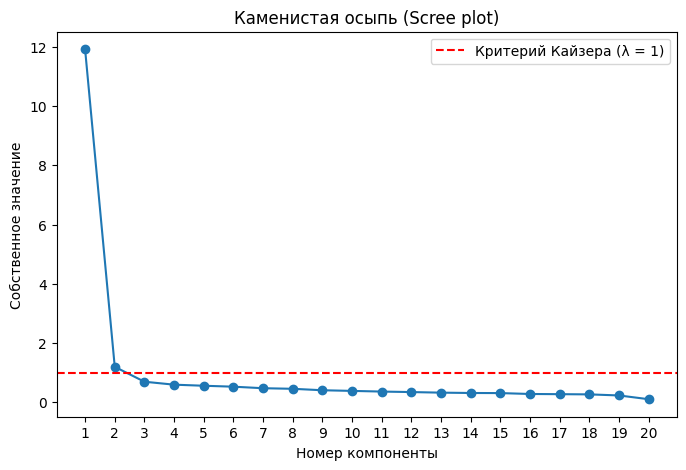

Число компонент по Кайзеру (λ >= 1): 2


In [40]:
# Получим собственные значения (eigenvalues)
eigenvalues = pca.explained_variance_

# Критерий Кайзера: оставляем компоненты с собственным значением > 1
n_kaiser = (eigenvalues > 1).sum()

# Критерий каменистой осыпи (scree plot): визуализация
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.xlabel('Номер компоненты')
plt.ylabel('Собственное значение')
plt.title('Каменистая осыпь (Scree plot)')
plt.axhline(1, color='red', linestyle='--', label='Критерий Кайзера (λ = 1)')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.show()

print(f"Число компонент по Кайзеру (λ >= 1): {n_kaiser}")

                               Factor1   Factor2
anxiety_level                 0.810748  0.231008
self_esteem                  -0.711593 -0.437068
mental_health_history         0.717897  0.202822
depression                    0.751293  0.350076
headache                      0.724373  0.284324
blood_pressure                0.120908  0.993406
sleep_quality                -0.806235 -0.204997
breathing_problem             0.660880  0.073348
noise_level                   0.650283  0.262623
living_conditions            -0.637404 -0.199675
safety                       -0.748139 -0.230628
basic_needs                  -0.745360 -0.213606
academic_performance         -0.766807 -0.191612
study_load                    0.630572  0.266101
teacher_student_relationship -0.747770 -0.300210
future_career_concerns        0.778797  0.333422
social_support               -0.514943 -0.687461
peer_pressure                 0.712468  0.282909
extracurricular_activities    0.693145  0.322589
bullying            

/Users/ilavoronin/Учеба/СИИиМО/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ilavoronin/Учеба/СИИиМО/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


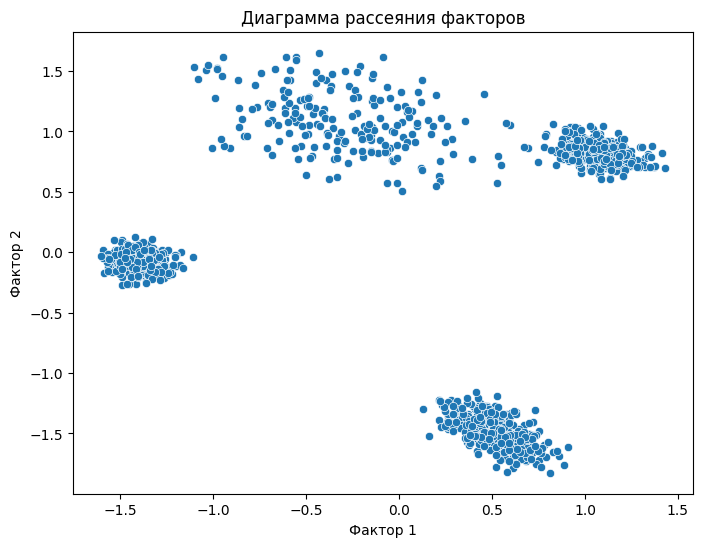

In [44]:
from factor_analyzer import FactorAnalyzer

n_factors = 2

# Вращение: Варимакс считается наиболее универсальным для социально-психологических исследований
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(X)

# Получение измененных нагрузок и объясненной дисперсии по факторам
rotated_loadings = pd.DataFrame(fa.loadings_, index=num_cols, columns=[f'Factor{i+1}' for i in range(n_factors)])
variance = pd.DataFrame({
    'Объясненная дисперсия': fa.get_factor_variance()[0],
    'Доля общей дисперсии': fa.get_factor_variance()[1],
    'Накопленная доля': fa.get_factor_variance()[2]
}, index=[f'Factor{i+1}' for i in range(n_factors)])

print(rotated_loadings)
print(variance)

factor_scores = fa.transform(X)  # X — стандартизированные данные
df_factors = pd.DataFrame(factor_scores, columns=[f'Factor{i+1}' for i in range(n_factors)])

plt.figure(figsize=(8,6))
sns.scatterplot(x='Factor1', y='Factor2', data=df_factors)
plt.title('Диаграмма рассеяния факторов')
plt.xlabel('Фактор 1')
plt.ylabel('Фактор 2')
plt.show()

|                               | Factor1   | Factor2   |
|-------------------------------|-----------|-----------|
| anxiety_level                 | 0.810748  | 0.231008  |
| self_esteem                   | -0.711593 | -0.437068 |
| mental_health_history         | 0.717897  | 0.202822  |
| depression                    | 0.751293  | 0.350076  |
| headache                      | 0.724373  | 0.284324  |
| blood_pressure                | 0.120908  | 0.993406  |
| sleep_quality                 | -0.806235 | -0.204997 |
| breathing_problem             | 0.660880  | 0.073348  |
| noise_level                   | 0.650283  | 0.262623  |
| living_conditions             | -0.637404 | -0.199675 |
| safety                        | -0.748139 | -0.230628 |
| basic_needs                   | -0.745360 | -0.213606 |
| academic_performance          | -0.766807 | -0.191612 |
| study_load                    | 0.630572  | 0.266101  |
| teacher_student_relationship  | -0.747770 | -0.300210 |
| future_career_concerns        | 0.778797  | 0.333422  |
| social_support                | -0.514943 | -0.687461 |
| peer_pressure                 | 0.712468  | 0.282909  |
| extracurricular_activities    | 0.693145  | 0.322589  |
| bullying                      | 0.793959  | 0.253934  |

| Фактор | Объясненная дисперсия | Доля общей дисперсии | Накопленная доля |
|--------|----------------------|----------------------|------------------|
| Factor1| 9.848931             | 0.492447             | 0.492447         |
| Factor2| 2.760846             | 0.138042             | 0.630489         |

Результаты вращения методом Варимакс позволяют выделить две хорошо различимые группы факторов (латентных переменных), каждая из которых отвечает за свою "тематику" внутри набора данных:

1. Factor 1 (Психосоциальный стресс и адаптация)
- Очень высокие положительные нагрузки имеют anxiety_level, depression, mental_health_history, headache, bullying, peer_pressure, future_career_concerns, extracurricular_activities, noise_level, breathing_problem, study_load.

- Очень высокие отрицательные нагрузки (значения −0.64…−0.81) — self_esteem, sleep_quality, safety, basic_needs, living_conditions, academic_performance, teacher_student_relationship, social_support.

- Интерпретация: этот фактор отражает общий уровень психологического, академического и социального напряжения у студентов. Высокие значения свидетельствуют о высоком уровне тревоги, депрессии, социальной изоляции, наличии головных болей, высокой учебной нагрузке и проблемах с будущим. Низкие значения характерны для студентов с высокой самооценкой, хорошим качеством сна, поддерживающей обстановкой и без выраженного стресса.

- Это — ядро "общего стресс-фактора", смешивающего психологические, психосоматические и социальные аспекты жизни.​

2. Factor 2 (Физиологические и поддерживающие ресурсы)
Главные признаки с высокой положительной нагрузкой — blood_pressure (+0.99), другие положительные – depression, headache, academic_performance, teacher_student_relationship, extracurricular_activities, bullying (все ниже +0.4).

- Значимые отрицательные нагрузки: social_support (−0.69), self_esteem (−0.44) — это индикаторы недостатка взаимопомощи, самоценности.

- Интерпретация: этот фактор преимущественно захватывает физиологические параметры (давление) и ресурсы поддержки. Высокие значения типичны для студентов с повышенным физиологическим напряжением при низком уровне внешней поддержки и самооценки. Негативные — для тех, кто ощущает поддержку и уверен в себе, даже при наличии слабых физиологических симптомов.

- Это — отражение "физиологического и ресурсного фактора" студенческого самочувствия.​

3. Вывод:
- Варимакс вращение успешно упростило структуру факторов: теперь каждая переменная в большей степени "закреплена" только за одним фактором.​

- В текущем исследовании исследовании первый фактор — это интегральный стресс-адаптационный индекс, а второй — физиолого-социальный ресурс (или обратный компонент социальной поддержки и самооценки).

- Эти два фактора вместе объясняют значительную (63%) долю общей дисперсии, что подтверждает потенциальную интерпретируемость результатов.